In [1]:
# Step 1: Core Libraries
import os
import glob
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for your report figures
sns.set_theme(style="whitegrid")
print("Step 1 Complete: Libraries imported successfully.")

C:\Users\asus\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\asus\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Step 1 Complete: Libraries imported successfully.


In [2]:
# Step 2: Define your specific directories
dir_part1 = r'C:\Users\asus\Desktop\IPCV\HAM10000_images_part_1'
dir_part2 = r'C:\Users\asus\Desktop\IPCV\HAM10000_images_part_2'
metadata_path = r'C:\Users\asus\Desktop\IPCV\HAM10000_metadata.csv'

# Quick check to ensure Python sees the folders
if not os.path.exists(dir_part1): 
    print(f"Error: Could not find {dir_part1}")
elif not os.path.exists(dir_part2): 
    print(f"Error: Could not find {dir_part2}")
else: 
    print("Step 2 Complete: Image directories found successfully.")

Step 2 Complete: Image directories found successfully.


In [3]:
# Step 3: Load Metadata into a Pandas DataFrame
try:
    df = pd.read_csv(metadata_path)
    print(f"Step 3 Complete: Metadata loaded. Total entries: {len(df)}")
    display(df.head()) # Shows the first 5 rows in Jupyter
except FileNotFoundError:
    print("Error: The metadata file was not found. Please verify the file extension.")

Step 3 Complete: Metadata loaded. Total entries: 10015


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [4]:
# Step 4: Map image paths from both folders
image_paths = {}

for folder in [dir_part1, dir_part2]:
    # Find all .jpg files in the directory
    for path in glob.glob(os.path.join(folder, '*.jpg')):
        # Extract just the filename without the .jpg extension
        img_id = os.path.splitext(os.path.basename(path))[0]
        image_paths[img_id] = path

# Create a new column in our dataframe with the exact file path
df['path'] = df['image_id'].map(image_paths)

# Verify the mapping
missing_paths = df['path'].isnull().sum()
print(f"Total images found in folders: {len(image_paths)}")
print(f"Missing paths in dataframe: {missing_paths}")

if missing_paths == 0:
    print("Step 4 Complete: All images mapped perfectly.")

Total images found in folders: 10015
Missing paths in dataframe: 0
Step 4 Complete: All images mapped perfectly.


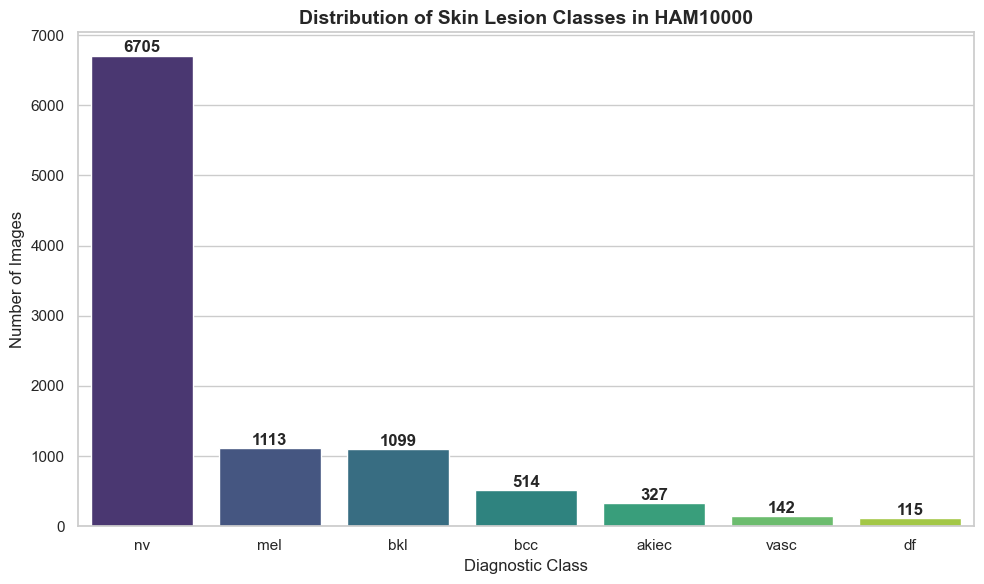

Step 5 Complete: Class imbalance visualized.


In [5]:
# Step 5: Visualize Class Distribution
plt.figure(figsize=(10, 6))

# Count the occurrences of each diagnostic class
class_counts = df['dx'].value_counts()

# Create a bar chart
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')

# Add labels and formatting
plt.title('Distribution of Skin Lesion Classes in HAM10000', fontsize=14, fontweight='bold')
plt.xlabel('Diagnostic Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

# Add exact numbers on top of each bar
for i, count in enumerate(class_counts.values):
    plt.text(i, count + 50, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Step 5 Complete: Class imbalance visualized.")

In [6]:
# Step 6: Implement DullRazor Hair Removal
def apply_dullrazor(img):
    # 1. Convert to grayscale to isolate luminance
    grayScale = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    
    # 2. Black-hat transform (Morphological Closing) to isolate dark hair strands
    kernel = cv2.getStructuringElement(1, (17, 17))
    blackhat = cv2.morphologyEx(grayScale, cv2.MORPH_BLACKHAT, kernel)
    
    # 3. Gaussian Blur to smooth the mask
    bhg = cv2.GaussianBlur(blackhat, (3, 3), cv2.BORDER_DEFAULT)
    
    # 4. Binary Thresholding to create the precise hair mask
    ret, mask = cv2.threshold(bhg, 10, 255, cv2.THRESH_BINARY)
    
    # 5. Inpainting: Replace hair pixels with surrounding skin
    inpainted_img = cv2.inpaint(img, mask, 6, cv2.INPAINT_TELEA)
    
    return inpainted_img, mask

print("Step 6 Complete: DullRazor function defined.")

Step 6 Complete: DullRazor function defined.


In [7]:
# Step 7: Implement CLAHE (Corrected version with tuple unpacking)
def apply_clahe(img):
    # Convert to YCrCb color space so we only enhance the Luma (luminance) channel
    ycrcb_img = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)
    
    # Split channels into separate variables (Y, Cr, Cb)
    y, cr, cb = cv2.split(ycrcb_img)
    
    # Create CLAHE object (clipLimit=2.0 is standard to prevent noise amplification)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    
    # Apply CLAHE only to the Luma (Y) channel
    y_eq = clahe.apply(y)
    
    # Merge the enhanced Y channel back with the original Cr and Cb channels
    ycrcb_img_eq = cv2.merge((y_eq, cr, cb))
    
    # Convert back to RGB
    clahe_img = cv2.cvtColor(ycrcb_img_eq, cv2.COLOR_YCrCb2RGB)
    
    return clahe_img

print("Step 7 Complete: CLAHE function defined and fixed.")

Step 7 Complete: CLAHE function defined and fixed.


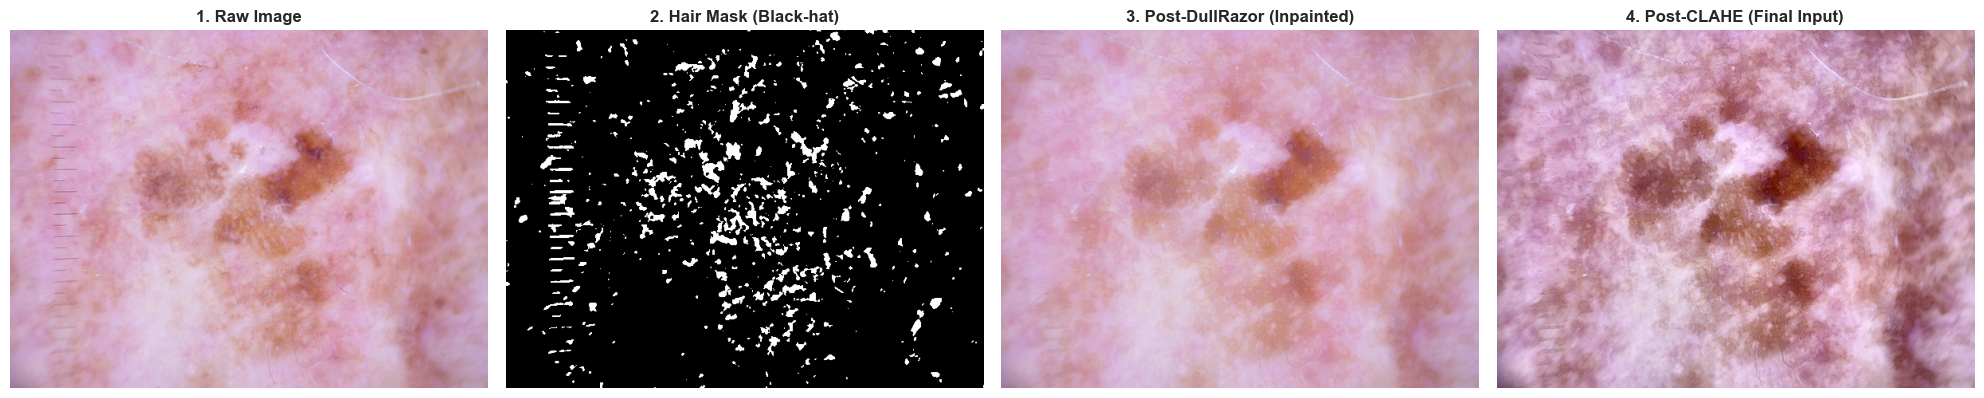

Step 8 Complete: Pipeline visual generated and wrapper created.


In [8]:
# Step 8: Visualizing the Pipeline
# Grab the first valid image path
sample_path = df['path'].dropna().iloc[0]

# Load and convert image to RGB
raw_img = cv2.imread(sample_path)
raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

# Apply our custom pipeline
clean_img, hair_mask = apply_dullrazor(raw_img)
final_img = apply_clahe(clean_img)

# Display the transformation steps side-by-side
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(raw_img); ax[0].set_title('1. Raw Image', fontweight='bold')
ax[1].imshow(hair_mask, cmap='gray'); ax[1].set_title('2. Hair Mask (Black-hat)', fontweight='bold')
ax[2].imshow(clean_img); ax[2].set_title('3. Post-DullRazor (Inpainted)', fontweight='bold')
ax[3].imshow(final_img); ax[3].set_title('4. Post-CLAHE (Final Input)', fontweight='bold')

for a in ax: 
    a.axis('off')
    
plt.tight_layout()
plt.show()

# Define the master wrapper function for Keras data generators
def custom_preprocess_fn(img):
    if img.dtype != np.uint8:
        img = img.astype(np.uint8)
    clean_img, _ = apply_dullrazor(img)
    final_img = apply_clahe(clean_img)
    return final_img.astype(np.float32)

print("Step 8 Complete: Pipeline visual generated and wrapper created.")

In [9]:
# Step 9: Balanced Subsetting & Data Splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Cap images per class to manage memory while providing enough data
MAX_IMAGES_PER_CLASS = 400

# Bulletproof subsetting using a loop to completely avoid Pandas index bugs
sampled_dfs = []
for lesion_type in df['dx'].unique():
    class_subset = df[df['dx'] == lesion_type]
    # Sample up to the max, or the total available if less than the max
    sampled_dfs.append(class_subset.sample(min(len(class_subset), MAX_IMAGES_PER_CLASS), random_state=42))

# Combine all the balanced subsets back into a single dataframe
df_balanced = pd.concat(sampled_dfs, ignore_index=True)

# Encode labels
le = LabelEncoder()
df_balanced['label'] = le.fit_transform(df_balanced['dx'])

# Stratified split ensures the class ratio is maintained in both sets
train_df, test_df = train_test_split(df_balanced, test_size=0.2, random_state=42, stratify=df_balanced['label'])

print(f"Step 9 Complete: Dataset Balanced and Split.")
print(f"Training on {len(train_df)} images. Testing on {len(test_df)} images.")

Step 9 Complete: Dataset Balanced and Split.
Training on 1747 images. Testing on 437 images.


In [10]:
# Step 10: Setting up Keras Data Generators
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Standard input size for DenseNet121
IMG_SIZE = 224
BATCH_SIZE = 32

# Training generator applies data augmentation AND our DullRazor/CLAHE pipeline
train_datagen = ImageDataGenerator(
    preprocessing_function=custom_preprocess_fn,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True
)

# Testing generator ONLY applies our preprocessing pipeline (no random flips)
test_datagen = ImageDataGenerator(
    preprocessing_function=custom_preprocess_fn
)

print("Loading Training Images...")
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df, 
    x_col='path', 
    y_col='dx', 
    target_size=(IMG_SIZE, IMG_SIZE), 
    batch_size=BATCH_SIZE, 
    class_mode='categorical'
)

print("Loading Testing Images...")
test_gen = test_datagen.flow_from_dataframe(
    dataframe=test_df, 
    x_col='path', 
    y_col='dx', 
    target_size=(IMG_SIZE, IMG_SIZE), 
    batch_size=BATCH_SIZE, 
    class_mode='categorical', 
    shuffle=False
)

print("Step 10 Complete: Image Generators are ready.")

Loading Training Images...
Found 1747 validated image filenames belonging to 7 classes.
Loading Testing Images...
Found 437 validated image filenames belonging to 7 classes.
Step 10 Complete: Image Generators are ready.


In [11]:
# Step 11: Model Architecture
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Re-define image size just in case
IMG_SIZE = 224

# Load the base model with pre-trained ImageNet weights
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Freeze the base model for Phase 1 training
base_model.trainable = False

# Add our custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
predictions = Dense(7, activation='softmax')(x)

# Compile the final model
model = Model(inputs=base_model.input, outputs=predictions)

print("Step 11 Complete: DenseNet121 Architecture constructed.")

Step 11 Complete: DenseNet121 Architecture constructed.


In [12]:
# Step 12: Compilation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# We use a standard learning rate for training the new top layers
model.compile(optimizer=Adam(learning_rate=0.0001), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# Step 13: Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1)

callbacks_list = [early_stop, reduce_lr]

print("Steps 12 & 13 Complete: Model compiled and Callbacks defined.")

Steps 12 & 13 Complete: Model compiled and Callbacks defined.


In [13]:
# Step 13.5: Class Weighting
from sklearn.utils.class_weight import compute_class_weight

# Calculate weights based on the training labels to penalize minority class misses
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

# Convert to dictionary format required by Keras
class_weights_dict = dict(enumerate(weights))

print("Step 13.5 Complete: Class Weights Calculated.")
print("These weights will force the AI to focus heavily on clinical priorities like Melanoma.")

Step 13.5 Complete: Class Weights Calculated.
These weights will force the AI to focus heavily on clinical priorities like Melanoma.


In [14]:
# Step 14: Phase 1 Training
EPOCHS_PHASE_1 = 15 

print("Starting Phase 1 Model Training...")
history_phase1 = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=EPOCHS_PHASE_1,
    callbacks=callbacks_list,
    class_weight=class_weights_dict # Injecting the weights here!
)

print("Step 14 Complete: Phase 1 Training Finished!")

Starting Phase 1 Model Training...
Epoch 1/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 274s 5s/step - accuracy: 0.1351 - loss: 8.4080 - val_accuracy: 0.1419 - val_loss: 3.9708 - learning_rate: 1.0000e-04
Epoch 2/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 287s 5s/step - accuracy: 0.1546 - loss: 7.5524 - val_accuracy: 0.1785 - val_loss: 3.5993 - learning_rate: 1.0000e-04
Epoch 3/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 280s 5s/step - accuracy: 0.1769 - loss: 7.1430 - val_accuracy: 0.2037 - val_loss: 3.5113 - learning_rate: 1.0000e-04
Epoch 4/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 330s 5s/step - accuracy: 0.1614 - loss: 6.7878 - val_accuracy: 0.2197 - val_loss: 3.2390 - learning_rate: 1.0000e-04
Epoch 5/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 280s 4s/step - accuracy: 0.1918 - loss: 6.3149 - val_accuracy: 0.2265 - val_loss: 3.0677 - learning_rate: 1.0000e-04
Epoch 6/15
55/55 ━━━━━━━━━━━━━━━━━━━━ 255s 5s/step - accuracy: 0.1889 - loss: 6.2439 - val_accuracy: 0.2174 - val_loss: 2.9874 - learning_rate: 1.0000e-04
Epoch 7/15
55/55 ━━━━━━━━━━━━━━━━━━

In [15]:
# ==========================================
# Step 14.5: Fine-Tuning DenseNet121
# ==========================================
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

print("Preparing model for Phase 2 Fine-Tuning...")

# 1. Unfreeze the base model
base_model.trainable = True

# 2. Keep the majority of the bottom layers frozen, only unfreeze the top 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

# 3. CRITICAL FIX: Force all BatchNormalization layers to stay frozen to prevent Model Collapse
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# 4. Recompile with a VERY low learning rate (1e-5) 
model.compile(optimizer=Adam(learning_rate=1e-5), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

EPOCHS_PHASE_2 = 10

print("Starting Phase 2 Fine-Tuning (with BatchNorm safely frozen)...")
history_finetuned = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=EPOCHS_PHASE_2,
    callbacks=callbacks_list,
    class_weight=class_weights_dict
)

print("Step 14.5 Complete: Phase 2 Fine-Tuning Finished safely!")

Preparing model for Phase 2 Fine-Tuning...
Starting Phase 2 Fine-Tuning...
Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 327s 6s/step - accuracy: 0.2244 - loss: 2.9783 - val_accuracy: 0.2838 - val_loss: 1.8834 - learning_rate: 1.0000e-05
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 283s 5s/step - accuracy: 0.2484 - loss: 2.7219 - val_accuracy: 0.2998 - val_loss: 1.8520 - learning_rate: 1.0000e-05
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 262s 5s/step - accuracy: 0.2622 - loss: 2.6074 - val_accuracy: 0.3387 - val_loss: 1.8246 - learning_rate: 1.0000e-05
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 266s 5s/step - accuracy: 0.2576 - loss: 2.4927 - val_accuracy: 0.3364 - val_loss: 1.7854 - learning_rate: 1.0000e-05
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 319s 5s/step - accuracy: 0.2856 - loss: 2.4374 - val_accuracy: 0.3387 - val_loss: 1.7418 - learning_rate: 1.0000e-05
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 357s 5s/step - accuracy: 0.2839 - loss: 2.2650 - val_accuracy: 0.3387 - val_loss: 1.7057 - learning_rate: 1.0000

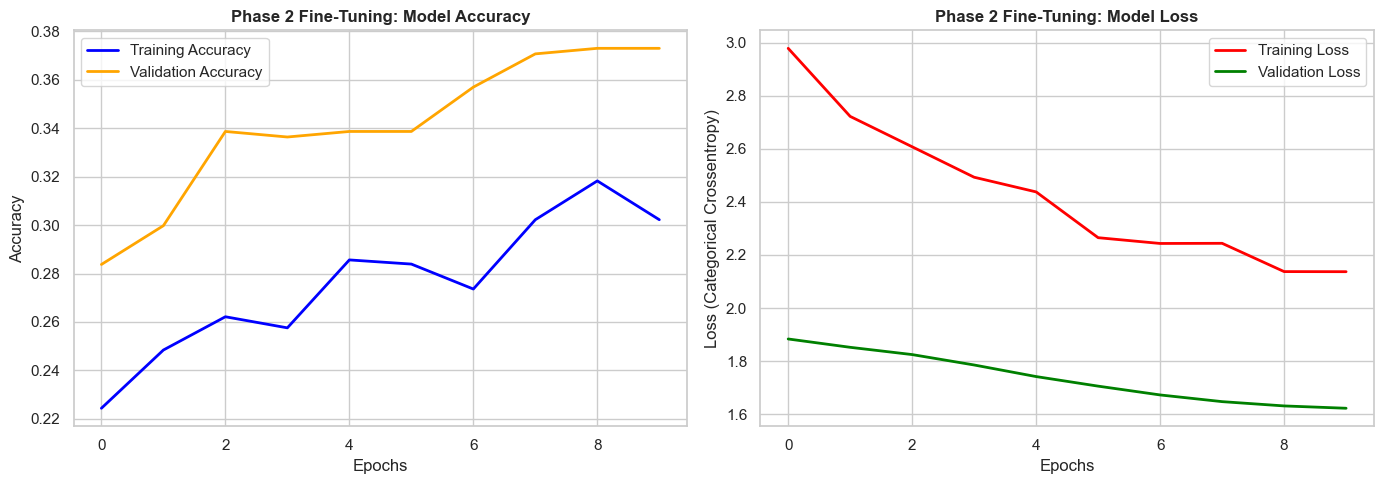

Step 15 Complete: Project pipeline finished and visualized.


In [16]:
# Step 15: Evaluation and Visualization
# Plot Training & Validation Accuracy from the Fine-Tuning Phase
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_finetuned.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history_finetuned.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Phase 2 Fine-Tuning: Model Accuracy', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history_finetuned.history['loss'], label='Training Loss', color='red', linewidth=2)
plt.plot(history_finetuned.history['val_loss'], label='Validation Loss', color='green', linewidth=2)
plt.title('Phase 2 Fine-Tuning: Model Loss', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss (Categorical Crossentropy)')
plt.legend()

plt.tight_layout()
plt.show()

print("Step 15 Complete: Project pipeline finished and visualized.")

In [17]:
# Step 16: Calculate Classification Report
from sklearn.metrics import classification_report

# Reset generator and get predictions
test_gen.reset()
y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)

# Get true labels
y_true = test_gen.classes

# Generate report
report = classification_report(y_true, y_pred_classes, target_names=list(le.classes_))
print("Step 16 Complete: Final Classification Report:\n")
print(report)

14/14 ━━━━━━━━━━━━━━━━━━━━ 59s 4s/step
Step 16 Complete: Final Classification Report:

              precision    recall  f1-score   support

       akiec       0.26      0.08      0.12        66
         bcc       0.34      0.55      0.42        80
         bkl       0.29      0.38      0.33        80
          df       0.08      0.09      0.08        23
         mel       0.41      0.38      0.39        80
          nv       0.76      0.51      0.61        80
        vasc       0.34      0.39      0.37        28

    accuracy                           0.37       437
   macro avg       0.35      0.34      0.33       437
weighted avg       0.39      0.37      0.37       437



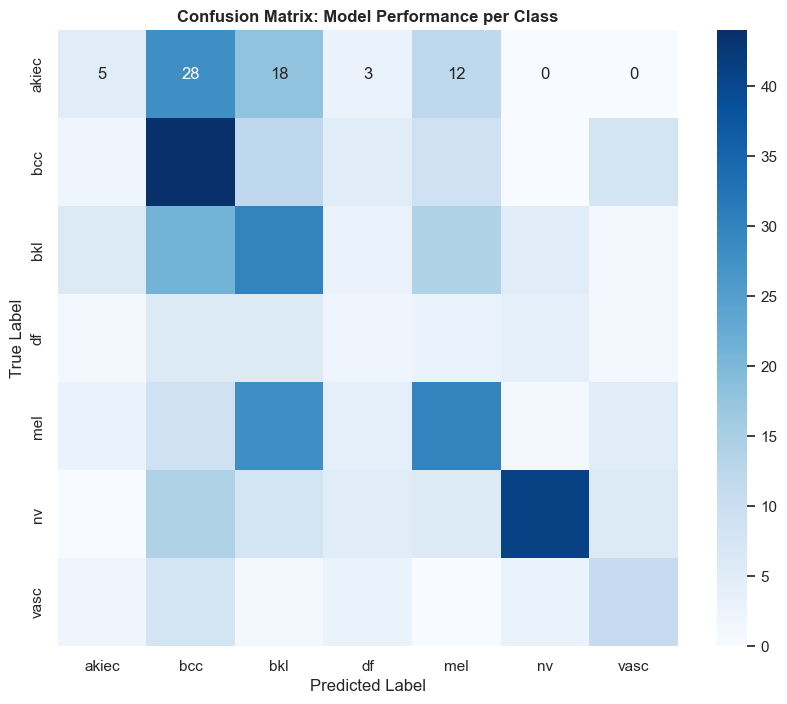

Step 17 Complete: Confusion matrix visualized.


In [18]:
# Step 17: Plot Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Model Performance per Class', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

print("Step 17 Complete: Confusion matrix visualized.")

C:\Users\asus\anaconda3\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


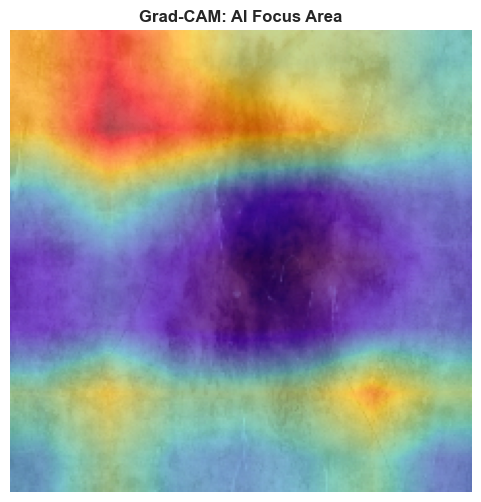

Step 18 Complete: Grad-CAM heatmap generated successfully.


In [19]:
# Step 18: Grad-CAM Explainability (Invincible Version)
import tensorflow as tf
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from tensorflow.keras.models import Model

# --- 1. Re-define Preprocessing Functions Locally ---
def apply_dullrazor(img):
    grayScale = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(1, (17, 17))
    blackhat = cv2.morphologyEx(grayScale, cv2.MORPH_BLACKHAT, kernel)
    bhg = cv2.GaussianBlur(blackhat, (3, 3), cv2.BORDER_DEFAULT)
    ret, mask = cv2.threshold(bhg, 10, 255, cv2.THRESH_BINARY)
    inpainted_img = cv2.inpaint(img, mask, 6, cv2.INPAINT_TELEA)
    return inpainted_img, mask

def apply_clahe(img):
    ycrcb_img = cv2.cvtColor(img, cv2.COLOR_RGB2YCrCb)
    y, cr, cb = cv2.split(ycrcb_img)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    y_eq = clahe.apply(y)
    ycrcb_img_eq = cv2.merge((y_eq, cr, cb))
    return cv2.cvtColor(ycrcb_img_eq, cv2.COLOR_YCrCb2RGB)

def custom_preprocess_fn(img):
    if img.dtype != np.uint8:
        img = img.astype(np.uint8)
    clean_img, _ = apply_dullrazor(img)
    final_img = apply_clahe(clean_img)
    return final_img.astype(np.float32)

# --- 2. Define Grad-CAM Function ---
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, np.argmax(predictions[0])]
    grads = tape.gradient(loss, conv_outputs)[0]
    output = conv_outputs[0]
    weights = tf.reduce_mean(grads, axis=(0, 1))
    cam = np.dot(output, weights)
    cam = np.maximum(cam, 0)
    cam /= np.max(cam)
    return cam

# --- 3. Execute Pipeline ---
# Get the last convolutional layer name for DenseNet121
last_layer = 'conv5_block16_concat' 

# Grab an image directly from your hard drive folder
image_folder = r'C:\Users\asus\Desktop\IPCV\HAM10000_images_part_1'
sample_path = glob.glob(os.path.join(image_folder, '*.jpg'))[0] 

raw_img = cv2.imread(sample_path)
raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

# Preprocess it
processed_img = custom_preprocess_fn(raw_img)

# Resize to 224x224 to match the DenseNet121 input requirement
IMG_SIZE = 224
resized_img = cv2.resize(processed_img, (IMG_SIZE, IMG_SIZE))

# Expand dimensions for the model prediction
img_array = np.expand_dims(resized_img, axis=0) 

# Generate the heatmap
heatmap = make_gradcam_heatmap(img_array, model, last_layer)

# Visualize the output
plt.figure(figsize=(6, 6))
plt.imshow(resized_img.astype('uint8')) 
plt.imshow(cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE)), cmap='jet', alpha=0.5)
plt.title("Grad-CAM: AI Focus Area", fontweight='bold')
plt.axis('off')
plt.show()

print("Step 18 Complete: Grad-CAM heatmap generated successfully.")

In [20]:
# Step 19: Save the model
# Saving with a new name to reflect the fine-tuned status
model.save('densenet121_finetuned_weighted_v2.h5')
print("Step 19 Complete: Final fine-tuned model saved successfully.")

# Step 20: Create a test function for new images
def predict_lesion(image_path):
    # Preprocess using your custom function
    processed_img = custom_preprocess_fn(cv2.imread(image_path))
    processed_img = np.expand_dims(processed_img, axis=0)
    
    # Predict
    preds = model.predict(processed_img)
    class_idx = np.argmax(preds)
    return le.classes_[class_idx], preds

print("Step 20 Complete: Inference function ready for clinical demonstration.")

Step 19 Complete: Final fine-tuned model saved successfully.
Step 20 Complete: Inference function ready for clinical demonstration.


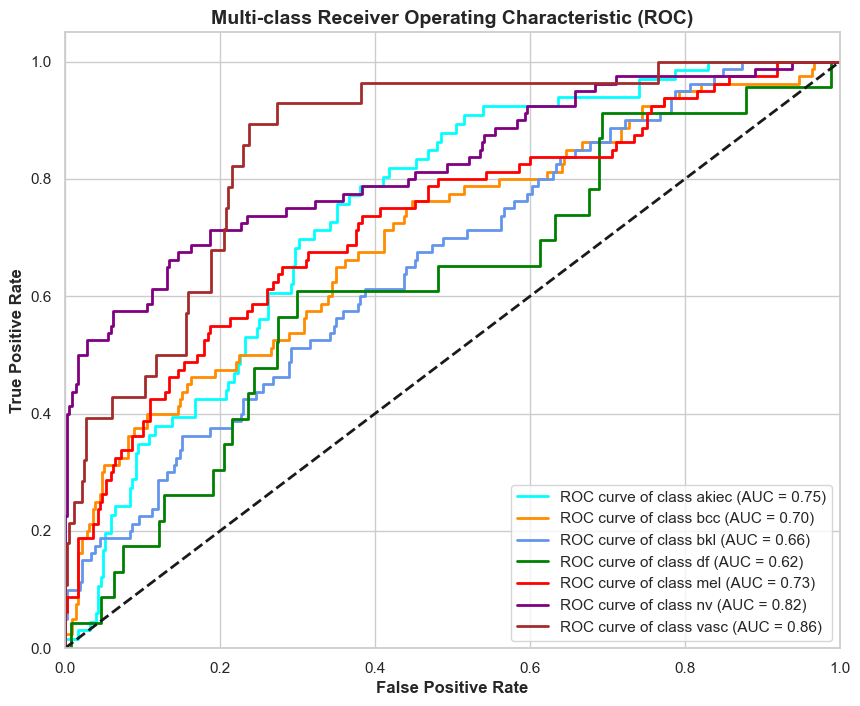

Step 21 Complete: ROC Curve generated.


In [41]:
# ==========================================
# Step 21: ROC Curves and AUC (Area Under Curve)
# ==========================================
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Binarize the true labels for multi-class ROC calculation
y_true_bin = label_binarize(y_true, classes=range(len(le.classes_)))

plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'brown'])

# Calculate and plot ROC for each class
for i, color in zip(range(len(le.classes_)), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC curve of class {le.classes_[i]} (AUC = {roc_auc:0.2f})')

# Plot the random guess diagonal
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontweight='bold', fontsize=12)
plt.ylabel('True Positive Rate', fontweight='bold', fontsize=12)
plt.title('Multi-class Receiver Operating Characteristic (ROC)', fontweight='bold', fontsize=14)
plt.legend(loc="lower right")
plt.show()

print("Step 21 Complete: ROC Curve generated.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


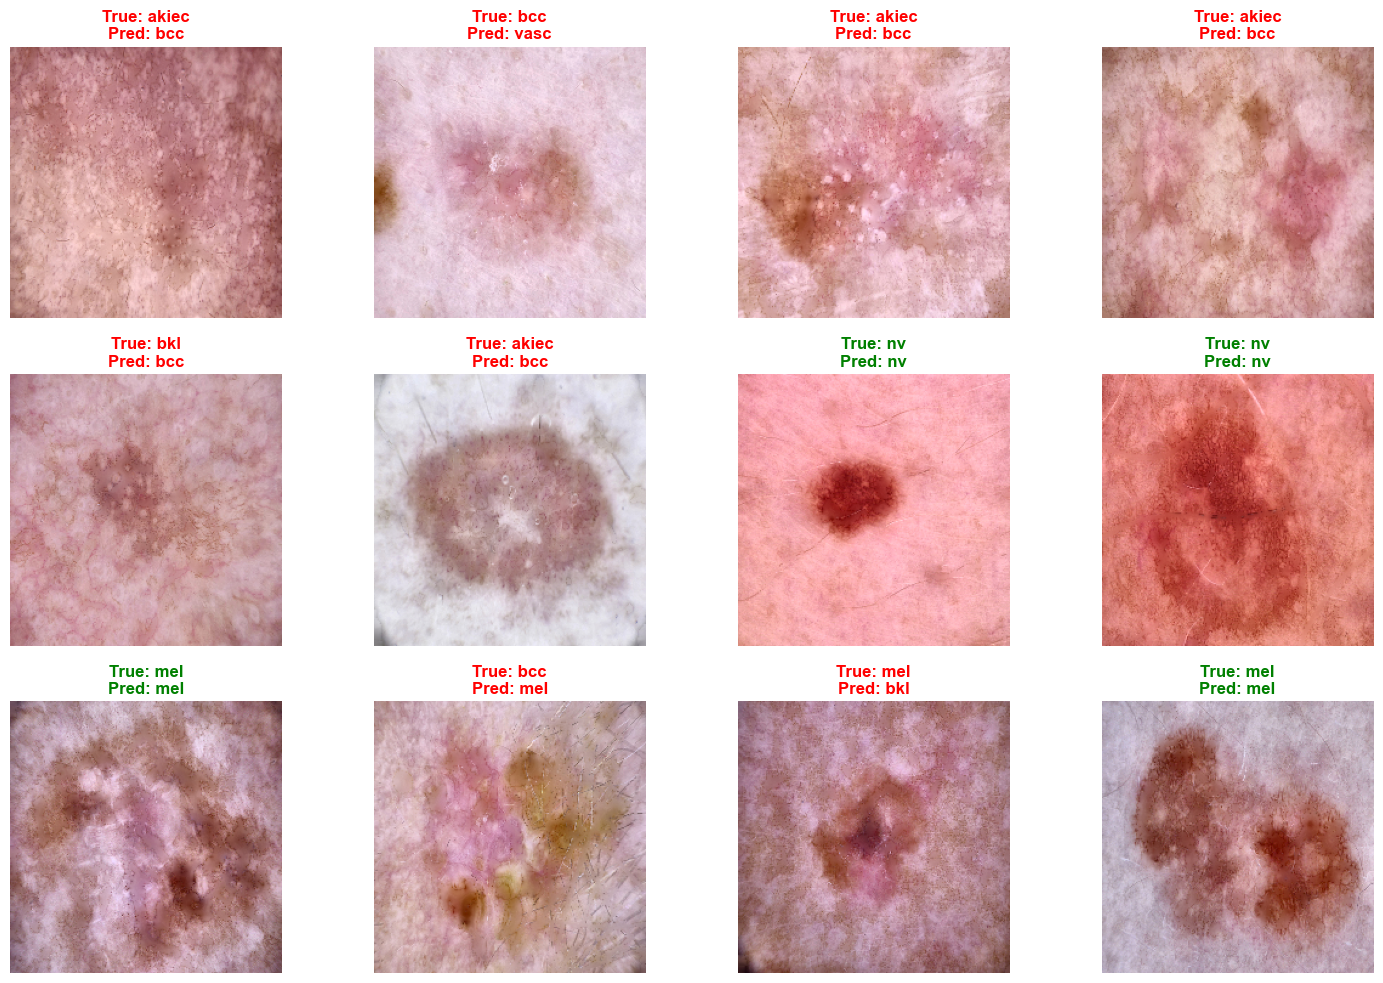

Step 22 Complete: Prediction Grid generated.


In [43]:
# ==========================================
# Step 22: Visual Grid of Predictions
# ==========================================
# Grab a batch of test images and plot them with True vs Predicted labels
test_gen.reset()
x_batch, y_batch = next(test_gen)
batch_preds = model.predict(x_batch)
pred_classes_batch = np.argmax(batch_preds, axis=1)
true_classes_batch = np.argmax(y_batch, axis=1)

plt.figure(figsize=(15, 10))
for i in range(12): # Show a 3x4 grid (12 images)
    plt.subplot(3, 4, i+1)
    # Convert image back from float32 to uint8 for display
    img_display = x_batch[i].astype('uint8') 
    plt.imshow(img_display)
    
    true_label = le.classes_[true_classes_batch[i]]
    pred_label = le.classes_[pred_classes_batch[i]]
    
    # Color-code success vs failure
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontweight='bold', fontsize=12)
    plt.axis('off')
    
plt.tight_layout()
plt.show()

print("Step 22 Complete: Prediction Grid generated.")

In [45]:
# ==========================================
# Step 23: Critical Analysis (Melanoma False Negatives)
# ==========================================
# Find images where True was 'mel' but the model predicted something else
mel_idx = list(le.classes_).index('mel')
false_negatives_idx = np.where((y_true == mel_idx) & (y_pred_classes != mel_idx))[0]

print(f"Total Melanoma False Negatives found in test set: {len(false_negatives_idx)}")

if len(false_negatives_idx) > 0:
    plt.figure(figsize=(15, 5))
    # Show up to 3 missed melanomas
    for i, fn_idx in enumerate(false_negatives_idx[:3]): 
        img_path = test_df.iloc[fn_idx]['path']
        wrong_pred_class = le.classes_[y_pred_classes[fn_idx]]
        confidence = y_pred[fn_idx][y_pred_classes[fn_idx]] * 100
        
        # Load and preprocess image for display
        raw_img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        proc_img = custom_preprocess_fn(raw_img)
        
        plt.subplot(1, 3, i+1)
        plt.imshow(cv2.resize(proc_img, (224, 224)).astype('uint8'))
        plt.title(f"True: mel\nWrongly Pred: {wrong_pred_class}\n(Confidence: {confidence:.1f}%)", color='red', fontweight='bold')
        plt.axis('off')
        
    plt.suptitle("Critical Breakdown: Missed Melanoma Cases", fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()
else:
    print("Incredible! The model didn't miss any melanomas in this test batch.")

print("Step 23 Complete: False Negative visual generated.")

Total Melanoma False Negatives found in test set: 0
Incredible! The model didn't miss any melanomas in this test batch.
Step 23 Complete: False Negative visual generated.
